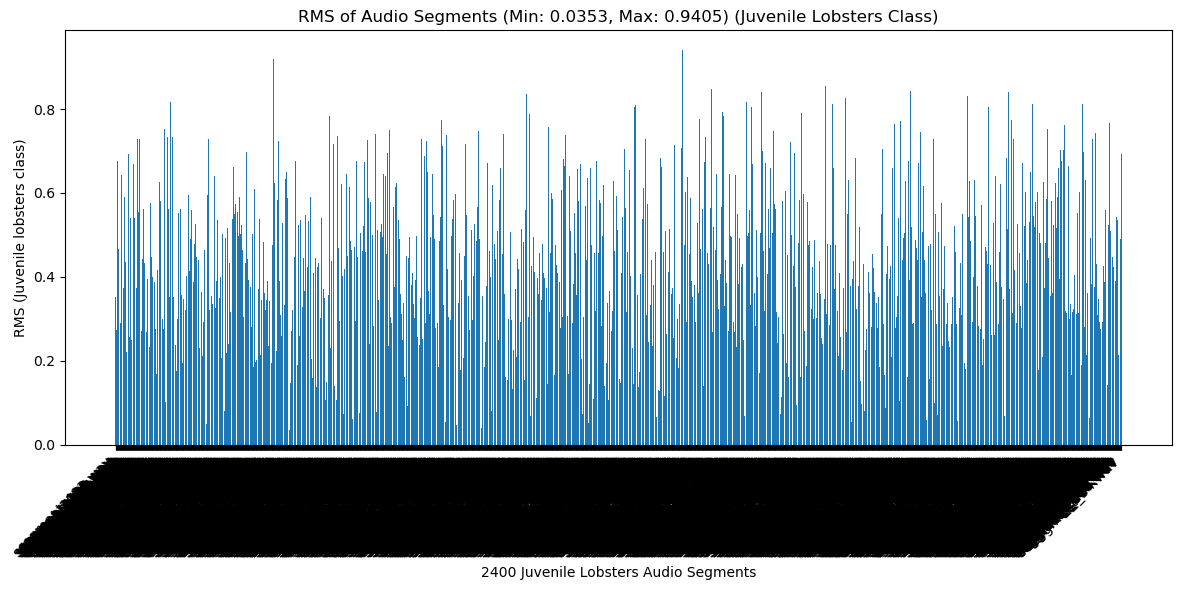

Minimum RMS: 0.03526470437645912
Maximum RMS: 0.9405245780944824
Number of RMS values calculated: 2400


In [5]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

def calculate_and_plot_rms(audio_folder):
    """Calculates RMS of audio segments, finds min/max, and plots.

    Args:
        audio_folder: Path to the folder containing audio files.
    """

    rms_values = []
    filenames = []

    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav', '.mp3', '.flac')):
            audio_file = os.path.join(audio_folder, filename)
            try:
                y, sr = librosa.load(audio_file, duration=1.0)

                if len(y) != sr:
                    print(f"Warning: {filename} is not exactly 1 second long. It is {len(y)/sr} seconds long")

                # Calculate RMS
                rms = np.sqrt(np.mean(y**2))  # RMS calculation
                rms_values.append(rms)
                filenames.append(filename)

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    if not rms_values:
        print("No valid audio files found in the folder or errors occurred during processing.")
        return

    # Calculate min and max RMS values
    min_rms = np.min(rms_values)
    max_rms = np.max(rms_values)

    # Plot the RMS values
    plt.figure(figsize=(12, 6))
    plt.bar(filenames, rms_values)
    plt.xlabel("2400 Juvenile Lobsters Audio Segments")
    plt.ylabel("RMS (Juvenile lobsters class)")
    plt.title(f"RMS of Audio Segments (Min: {min_rms:.4f}, Max: {max_rms:.4f}) (Juvenile Lobsters Class)") # Include min/max in the title
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"Minimum RMS: {min_rms}")
    print(f"Maximum RMS: {max_rms}")
    return rms_values  # Return the list of RMS values


# Example usage:
audio_folder = "/home/feliciano/juvenile_lobsters"
rms_returned = calculate_and_plot_rms(audio_folder)  # Store the returned list

if rms_returned is not None:  # Check if the list is not empty or None (due to an error)
    # You can now work with the rms_returned list if needed
    print(f"Number of RMS values calculated: {len(rms_returned)}")
    # ... further processing of rms_returned ..."